# Анализ продаж и популярности мероприятий Яндекс.Афиша
Автор: Повшедная Наталья

Дата: 21.09.2026

## 1. Введение
### 1.1 Цели и задачи проекта
#### Цель проекта

Провести исследовательский анализ данных Яндекс Афиши, чтобы выявить изменения пользовательского спроса и популярности мероприятий осенью 2024 года, а также сравнить поведение пользователей мобильных и стационарных устройств.

#### Задачи проекта

- Загрузить данные и оценить их объём, качество и соответствие описанию.
- Провести предобработку данных: обработать пропуски и дубликаты, проверить значения и типы данных, выявить выбросы.
- Привести выручку к единой валюте — российскому рублю — и рассчитать дополнительные показатели.
- Исследовать сезонные изменения количества заказов и распределения спроса по типам мероприятий, устройствам и возрастным категориям.
- Сравнить среднюю выручку с одного билета летом и осенью 2024 года.
- Проанализировать активность пользователей осенью: количество заказов, DAU, количество заказов на пользователя и среднюю стоимость билета.
- Исследовать недельную цикличность пользовательской активности.
- Определить наиболее популярные регионы и билетных партнёров по количеству мероприятий, заказов и выручке.
- Проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.
- Сформулировать основные выводы и рекомендации на основе результатов исследования.


### 1.2 Описание данных
датасет **final_tickets_orders_df.csv** включает информацию обо всех заказах билетов, совершённых с двух типов устройств
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev количество дней с предыдущей покупки для каждого пользователя.

датасет **final_tickets_events_df** содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год.
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).


## 2. Знакомство с данными
### 2.1 Загрузка данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu

import warnings

warnings.filterwarnings("ignore")
import jupyter_black

jupyter_black.load()

In [2]:
# выгружаем датасеты
df_orders = pd.read_csv(
    "https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv"
)
df_events = pd.read_csv(
    "https://code.s3.yandex.net/datasets/final_tickets_events_df.csv"
)
df_curs = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

In [3]:
# посмотрим на выгруженные датасеты
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 3

In [5]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


In [7]:
df_curs.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


**Датасет df_orders**: 14 столбцов и 290849 строк, данные полные, кроме столбца days_since_prev, нужно поменять тип данных в столбцах created_dt_msk и created_ts_msk на datetime, проверить наличие дубликатов и аномальных значений, строковые столбцы проверить на пробелы  
**Датасет df_events**: 11 столбцов и 22427 строк, данные полные, типы данных верные, проверить наличие дубликатов и аномальных значений, строковые столбцы проверить на пробелы  
**Датасет df_curs**: 4 столбца, 357 строк, данные полные, нужно поменять тип данных в столбце data на datetime  

После предобработки данных датасеты можно будет объединить


### 2.2 Предобработка данных и подготовка их к исследованию

In [9]:
# удаляем пробелы в начале и конце строковых значений
for df in [df_orders, df_events, df_curs]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

In [10]:
# проверим данные на наличие лишних значений
df_orders["device_type_canonical"].value_counts()

device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64

In [11]:
df_orders["currency_code"].value_counts()

currency_code
rub    285780
kzt      5069
Name: count, dtype: int64

In [12]:
df_orders["cinema_circuit"].value_counts()

cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64

In [13]:
# тк фильмы были исключены из датасета df_events, следует исключить столбец cinema_circuit
df_orders = df_orders.drop(columns="cinema_circuit")

In [14]:
# поменяй тип данных в столбцах с датой
df_orders["created_dt_msk"] = pd.to_datetime(df_orders["created_dt_msk"])
df_orders["created_ts_msk"] = pd.to_datetime(df_orders["created_ts_msk"])
df_curs["data"] = pd.to_datetime(df_curs["data"])

In [15]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  str           
 2   created_dt_msk         290849 non-null  datetime64[us]
 3   created_ts_msk         290849 non-null  datetime64[us]
 4   event_id               290849 non-null  int64         
 5   age_limit              290849 non-null  int64         
 6   currency_code          290849 non-null  str           
 7   device_type_canonical  290849 non-null  str           
 8   revenue                290849 non-null  float64       
 9   service_name           290849 non-null  str           
 10  tickets_count          290849 non-null  int64         
 11  total                  290849 non-null  float64       
 12  days_since_prev        268909 non-null  float64       


In [16]:
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [17]:
# посмотрим на наличие выбросов по типу валют
df_orders.groupby("currency_code")["revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.1000,3698.83,7397.66,26425.86
rub,285780.0,547.568333,871.524559,-90.76,113.8275,346.10,791.70,81174.54


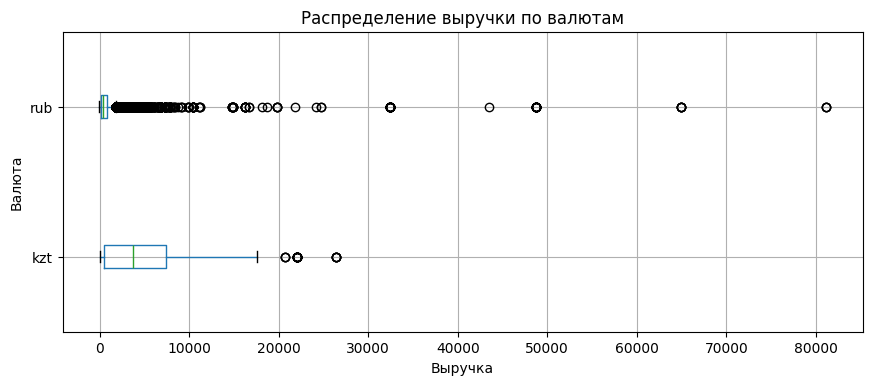

In [18]:
df_orders.boxplot(column="revenue", by="currency_code", vert=False, figsize=(10, 4))

plt.title("Распределение выручки по валютам")
plt.suptitle("")
plt.xlabel("Выручка")
plt.ylabel("Валюта")
plt.show()

In [19]:
# отберем значения по 99-му процентилю в revenue по валютам
rub_99 = df_orders.loc[df_orders["currency_code"] == "rub", "revenue"].quantile(0.99)

kzt_99 = df_orders.loc[df_orders["currency_code"] == "kzt", "revenue"].quantile(0.99)

df_orders = df_orders[
    ((df_orders["currency_code"] == "rub") & (df_orders["revenue"] <= rub_99))
    | ((df_orders["currency_code"] == "kzt") & (df_orders["revenue"] <= kzt_99))
].copy()

In [20]:
# посмотрим на выбросы по кол-ву билетов tickets_count
df_orders.groupby("currency_code")["tickets_count"].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5040.0,2.748413,1.101784,1.0,2.0,3.0,3.0,6.0
rub,282922.0,2.739737,1.163352,1.0,2.0,3.0,3.0,57.0


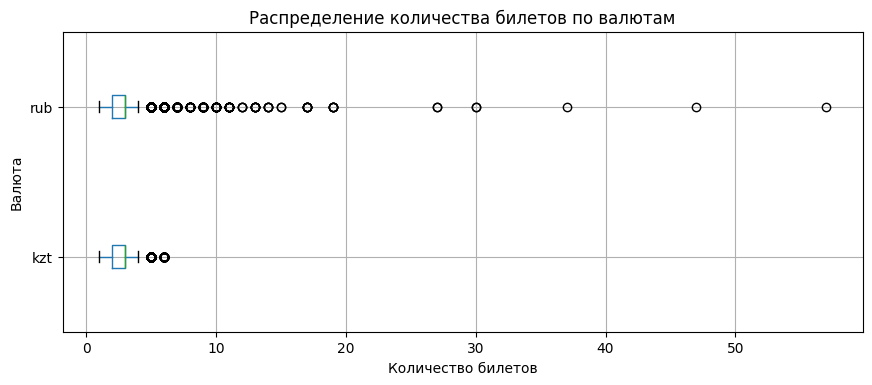

In [21]:
df_orders.boxplot(
    column="tickets_count", by="currency_code", vert=False, figsize=(10, 4)
)

plt.title("Распределение количества билетов по валютам")
plt.suptitle("")
plt.xlabel("Количество билетов")
plt.ylabel("Валюта")
plt.show()

In [22]:
# проверим на неявные дубликаты, не учитывая order_id
booking_cols = [
    "user_id",
    "created_dt_msk",
    "created_ts_msk",
    "event_id",
    "age_limit",
    "currency_code",
    "device_type_canonical",
    "revenue",
    "service_name",
    "tickets_count",
    "total",
    "days_since_prev",
]

df_orders.duplicated(subset=booking_cols).sum()

np.int64(30)

In [23]:
duplicates_booking = df_orders[
    df_orders.duplicated(subset=booking_cols, keep=False)
].sort_values(booking_cols)

duplicates_booking.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


результат показывает, что записи полностью совпадают по всем признакам бронирования и отличаются только order_id, что выглядит как техническая ошибка, их логично считать дубликатами и оставить по одной записи

In [24]:
df_orders = df_orders.drop_duplicates(subset=booking_cols, keep="first").copy()

In [25]:
df_orders.duplicated(subset=booking_cols).sum()

np.int64(0)

объединим обработанные датафреймы и добавим новые столбцы:  
**revenue_rub** — выручка с заказа в единой валюте — российский рубль.   
**one_ticket_revenue_rub** — выручка с продажи одного билета на мероприятие.  
**month** — месяц оформления заказа.  
**season** — информация о сезонности, включает такие категории, как: 'лето', 'осень', 'зима', 'весна'.  

In [26]:
df = df_orders.merge(df_events, on="event_id", how="left")

In [27]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,16,rub,mobile,1521.94,Край билетов,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,0,rub,mobile,289.45,Мой билет,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,0,rub,mobile,1258.57,За билетом!,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,0,rub,mobile,8.49,Лови билет!,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,18,rub,mobile,1390.41,Билеты без проблем,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [28]:
df = df.merge(
    df_curs[["data", "curs"]], left_on="created_dt_msk", right_on="data", how="left"
)

In [29]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,...,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,curs
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,16,rub,mobile,1521.94,Край билетов,...,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,18.6972
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,0,rub,mobile,289.45,Мой билет,...,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,18.3419
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,0,rub,mobile,1258.57,За билетом!,...,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,0,rub,mobile,8.49,Лови билет!,...,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,18.5010
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,18,rub,mobile,1390.41,Билеты без проблем,...,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648


In [30]:
# создадим столбец revenue_rub
df["revenue_rub"] = df["revenue"]

df.loc[df["currency_code"] == "kzt", "revenue_rub"] = (
    df.loc[df["currency_code"] == "kzt", "revenue"]
    * df.loc[df["currency_code"] == "kzt", "curs"]
    / 100
)

In [32]:
df.loc[
    df["currency_code"] == "kzt", ["currency_code", "revenue", "curs", "revenue_rub"]
].head(10)

,currency_code,revenue,curs,revenue_rub
73,kzt,518.10,19.0125,98.503762
91,kzt,347.18,18.9330,65.731589
98,kzt,328.77,18.5991,61.148261
465,kzt,7397.66,19.9833,1478.296591
466,kzt,3698.83,19.9833,739.148295
467,kzt,7397.66,19.9833,1478.296591
468,kzt,5548.24,19.9833,1108.721444
469,kzt,7397.66,19.9833,1478.296591
520,kzt,361.08,18.4217,66.517074
521,kzt,361.08,18.4217,66.517074


In [34]:
# выручка с продажи одного билета one_ticket_revenue_rub
df["one_ticket_revenue_rub"] = df["revenue_rub"] / df["tickets_count"]

In [36]:
df[["revenue_rub", "tickets_count", "one_ticket_revenue_rub"]].head()

,revenue_rub,tickets_count,one_ticket_revenue_rub
0,1521.94,4,380.4850
1,289.45,2,144.7250
2,1258.57,4,314.6425
3,8.49,2,4.2450
4,1390.41,3,463.4700


In [37]:
# month — месяц оформления заказа
df["month"] = df["created_dt_msk"].dt.month

In [42]:
# season — информация о сезонности, включает такие категории, как: 'лето', 'осень', 'зима', 'весна'.
seasons = {
    12: "зима",
    1: "зима",
    2: "зима",
    3: "весна",
    4: "весна",
    5: "весна",
    6: "лето",
    7: "лето",
    8: "лето",
    9: "осень",
    10: "осень",
    11: "осень",
}

df["season"] = df["month"].map(seasons)

In [41]:
df[["created_dt_msk", "month", "season"]].head(5)

,created_dt_msk,month,season
0,2024-08-20,8,лето
1,2024-07-23,7,лето
2,2024-10-06,10,осень
3,2024-07-13,7,лето
4,2024-10-04,10,осень


In [43]:
df.shape

(287932, 29)